# Day 14 - Sentiment Analysis using Hugging Face Transformers

## Objective

In this project, we will use a pre-trained Hugging Face model to classify customer reviews into Positive, Negative, or Neutral sentiments without training a model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

from transformers import pipeline

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

In [2]:
df = pd.read_csv("../datasets/product_reviews.csv")

df.head()

,Text,Label,Window,User Name,User ID
0,"It works as described, no major issues.",Neutral,Flipkart,Arjun Singh,U1001
1,Customer service was unhelpful and rude.,Negative,Flipkart,Vikram Joshi,U1002
2,"Amazing quality, totally worth the price.",Positive,Flipkart,Ananya Roy,U1003
3,"I am very satisfied with my purchase, highly r...",Positive,Flipkart,Vikram Joshi,U1004
4,"I am disappointed, it did not meet my expectat...",Negative,Flipkart,Raj Verma,U1005


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Text       1000 non-null   str  
 1   Label      1000 non-null   str  
 2   Window     1000 non-null   str  
 3   User Name  1000 non-null   str  
 4   User ID    1000 non-null   str  
dtypes: str(5)
memory usage: 39.2 KB


In [4]:
df.isnull().sum()

Text         0
Label        0
Window       0
User Name    0
User ID      0
dtype: int64

In [5]:
df.describe(include="all")

,Text,Label,Window,User Name,User ID
count,1000,1000,1000,1000,1000
unique,15,3,2,8,1000
top,"I am disappointed, it did not meet my expectat...",Neutral,Amazon,Neha Gupta,U1001
freq,80,344,509,140,1


## Text Cleaning using Regular Expressions

In [6]:
def clean_text(text):

    text = str(text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

In [7]:
df["Cleaned_Text"] = df["Text"].apply(clean_text)

In [8]:
df[["Text", "Cleaned_Text"]].head()

,Text,Cleaned_Text
0,"It works as described, no major issues.",It works as described no major issues
1,Customer service was unhelpful and rude.,Customer service was unhelpful and rude
2,"Amazing quality, totally worth the price.",Amazing quality totally worth the price
3,"I am very satisfied with my purchase, highly r...",I am very satisfied with my purchase highly re...
4,"I am disappointed, it did not meet my expectat...",I am disappointed it did not meet my expectations


In [9]:
df["Cleaned_Text"].isnull().sum()

np.int64(0)

## Load Pre-trained Sentiment Analysis Model

In [10]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=-1
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

## Run Sentiment Analysis

In [11]:
results = sentiment_pipeline(df["Cleaned_Text"].tolist())


In [12]:
results[:5]

[{'label': 'POSITIVE', 'score': 0.9905894994735718},
 {'label': 'NEGATIVE', 'score': 0.9997162222862244},
 {'label': 'POSITIVE', 'score': 0.9998859167098999},
 {'label': 'POSITIVE', 'score': 0.9998338222503662},
 {'label': 'NEGATIVE', 'score': 0.9997794032096863}]

In [13]:
predicted_sentiments = []
confidence_scores = []

for result in results:
    predicted_sentiments.append(result["label"].capitalize())
    confidence_scores.append(round(result["score"], 4))

In [14]:
df["Predicted_Sentiment"] = predicted_sentiments
df["Confidence_Score"] = confidence_scores

In [15]:
df[["Text", "Predicted_Sentiment", "Confidence_Score"]].head()

,Text,Predicted_Sentiment,Confidence_Score
0,"It works as described, no major issues.",Positive,0.9906
1,Customer service was unhelpful and rude.,Negative,0.9997
2,"Amazing quality, totally worth the price.",Positive,0.9999
3,"I am very satisfied with my purchase, highly r...",Positive,0.9998
4,"I am disappointed, it did not meet my expectat...",Negative,0.9998


## Create Final Sentiment Labels

In [16]:
final_sentiments = []

for sentiment, score in zip(df["Predicted_Sentiment"], df["Confidence_Score"]):
    
    if score < 0.70:
        final_sentiments.append("Neutral")
    else:
        final_sentiments.append(sentiment)

df["Final_Sentiment"] = final_sentiments

In [17]:
df[["Text", "Final_Sentiment", "Confidence_Score"]].head()

,Text,Final_Sentiment,Confidence_Score
0,"It works as described, no major issues.",Positive,0.9906
1,Customer service was unhelpful and rude.,Negative,0.9997
2,"Amazing quality, totally worth the price.",Positive,0.9999
3,"I am very satisfied with my purchase, highly r...",Positive,0.9998
4,"I am disappointed, it did not meet my expectat...",Negative,0.9998


## Sentiment Distribution

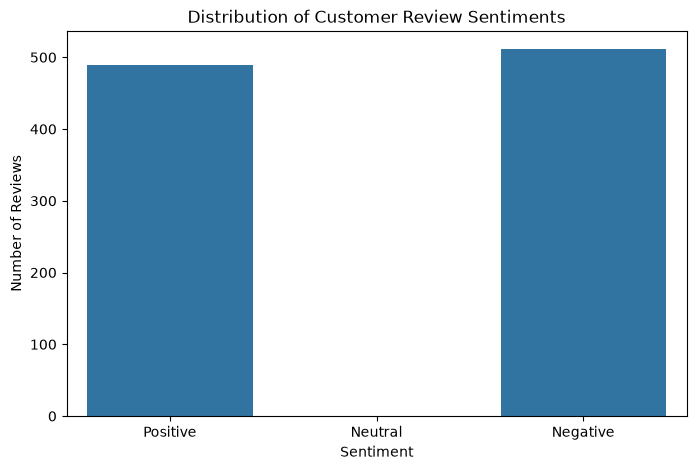

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Final_Sentiment",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Distribution of Customer Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [19]:
df["Final_Sentiment"].value_counts()

Final_Sentiment
Negative    511
Positive    489
Name: count, dtype: int64

## Export Final Dataset

In [20]:
df.to_csv("sentiment_analysis_results.csv", index=False)

print("CSV exported successfully!")

CSV exported successfully!


In [21]:
pd.read_csv("sentiment_analysis_results.csv").head()

,Text,Label,Window,User Name,User ID,Cleaned_Text,Predicted_Sentiment,Confidence_Score,Final_Sentiment
0,"It works as described, no major issues.",Neutral,Flipkart,Arjun Singh,U1001,It works as described no major issues,Positive,0.9906,Positive
1,Customer service was unhelpful and rude.,Negative,Flipkart,Vikram Joshi,U1002,Customer service was unhelpful and rude,Negative,0.9997,Negative
2,"Amazing quality, totally worth the price.",Positive,Flipkart,Ananya Roy,U1003,Amazing quality totally worth the price,Positive,0.9999,Positive
3,"I am very satisfied with my purchase, highly r...",Positive,Flipkart,Vikram Joshi,U1004,I am very satisfied with my purchase highly re...,Positive,0.9998,Positive
4,"I am disappointed, it did not meet my expectat...",Negative,Flipkart,Raj Verma,U1005,I am disappointed it did not meet my expectations,Negative,0.9998,Negative


## Conclusion

In this project, customer reviews were cleaned using Regular Expressions and analyzed using a pre-trained Hugging Face sentiment analysis model. The predicted sentiment and confidence score were added to the dataset. Finally, the sentiment distribution was visualized and the updated dataset was exported as a CSV file.

Using a pre-trained model allows us to perform accurate sentiment analysis without training a deep learning model from scratch, making NLP tasks faster and more efficient.